## TO DO
create complete script with click option able to:

    - read txt events as a function of N (eventually labels and features)
    - preprocess dataset
    - define NN: train, test, save model

## Preprocessing with Pandas

In [5]:
import sys
import numpy as np
import os
import pickle
import copy
import argparse
import pandas as pd

In [9]:
file_txt = 'sample_longitudinal.txt' #'sample_flat_train.txt' for flat generation, 'sample_longitudinal_train.txt' for generation according to |M_L|^2

features = ['i','rl','E','px','py','pz','E','-px','-py','-pz']

In [10]:
num_lines = sum(1 for line in open(file_txt))
num_lines

100

In [11]:
df = pd.DataFrame(columns=features)

In [12]:
for line in open(file_txt):
   df.loc[line.split()[0]] = [round(float(i),3) for i in line.split()]

In [13]:
df

,i,rl,E,px,py,pz,E,-px,-py,-pz
0,0.0,1.487,40.095,-0.985,0.148,0.092,40.095,0.985,-0.148,-0.092
1,1.0,0.422,40.095,-0.308,-0.432,-0.848,40.095,0.308,0.432,0.848
2,2.0,1.450,40.095,-0.501,-0.846,0.182,40.095,0.501,0.846,-0.182
3,3.0,0.579,40.095,-0.099,-0.613,0.784,40.095,0.099,0.613,-0.784
4,4.0,0.476,40.095,0.046,-0.561,-0.826,40.095,-0.046,0.561,0.826
...,...,...,...,...,...,...,...,...,...,...
95,95.0,1.269,40.095,0.357,0.848,0.392,40.095,-0.357,-0.848,-0.392
96,96.0,1.490,40.095,0.819,-0.568,0.083,40.095,-0.819,0.568,-0.083
97,97.0,1.455,40.095,0.904,0.390,0.173,40.095,-0.904,-0.390,-0.173
98,98.0,1.280,40.095,-0.836,0.393,-0.383,40.095,0.836,-0.393,0.383


## preprocessing with numpy for NN implementation
NB no standardization applied

In [1]:
import numpy as np
import torch

# load data
file_txt = 'sample_longitudinal_train.txt' #'sample_flat_train.txt' for flat generation, 'sample_longitudinal_train.txt' for generation according to |M_L|^2
train_dataset = np.loadtxt(file_txt)
features = train_dataset[:,[3,4,5,7,8,9]]
label = train_dataset[:,1]

file_txt_val = 'sample_longitudinal.txt'
val_dataset = np.loadtxt(file_txt_val)
val_features = val_dataset[:,[3,4,5,7,8,9]]
val_label = val_dataset[:,1]

In [2]:
# check dataset size and dimension
dataset_size = train_dataset.shape[0]
input_dim = features.shape[1]
output_dim = 1 # regression
print("Total events used in training: ", dataset_size) 
print("feature dimension: ", input_dim)
print("label dimension: ", output_dim)

val_dataset_size = val_dataset.shape[0]

Total events used in training:  60000
feature dimension:  6
label dimension:  1


In [3]:
features = torch.from_numpy(features)
label = torch.from_numpy(label)

val_features = torch.from_numpy(val_features)
val_label = torch.from_numpy(val_label)

In [4]:
features = features.float()
label = label.float()

val_features = val_features.float()
val_label = val_label.float()

In [5]:
print("feature data type: ", features.dtype)
print("feature shape: ", features.shape)
print("label type: ", label.shape)

feature data type:  torch.float32
feature shape:  torch.Size([60000, 6])
label type:  torch.Size([60000])


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# define training model
class Net(nn.Module):
    def __init__(self, in_dim, out_dim, emb_dim):
        super(Net, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.emb_dim = emb_dim
        self.head = nn.Linear(self.in_dim, self.emb_dim[0])
        self.linear1 = nn.Linear(self.emb_dim[0], self.emb_dim[1])
        # self.linear2 = nn.Linear(self.emb_dim[1], self.emb_dim[2])
        # self.linear3 = nn.Linear(self.emb_dim[2], self.emb_dim[1])
        self.linear4 = nn.Linear(self.emb_dim[1], self.emb_dim[0])
        # self.linear5 = nn.Linear(self.emb_dim[0], self.in_dim)
        self.out = nn.Linear(self.emb_dim[0], self.out_dim)

    def forward(self, x):
        x1 = F.relu(self.head(x))
        x2 = F.relu(self.linear1(x1)) #x2 = nn.Sigmoid(self.linear1(x1))#  
        # x3 = F.relu(self.linear2(x2))
        # x4 = F.relu(self.linear3(x3))
        x5 = F.relu(self.linear4(x2))
        # x6 = F.relu(self.linear5(x5))
        out = self.out(x5)

        return out

# initialization
model = Net(input_dim, output_dim, emb_dim = [16, 32]) # [16, 32, 64])

In [7]:
print(model(features[0]))
print(model(features[1]))
# print(features[0])
# print(val_features[0])
print(model(val_features[0]))

tensor([-0.2600], grad_fn=<AddBackward0>)
tensor([-0.2585], grad_fn=<AddBackward0>)
tensor([-0.2531], grad_fn=<AddBackward0>)


In [8]:
import time
# trainning config
mse_loss = torch.nn.MSELoss() # torch.nn.L1Loss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001, alpha=0.99, eps=1e-08, weight_decay=0, momentum=0)
check_point = 1000

# define trainning: per sample trainning
def train(epoch, train_loss_log):
    loss = 0
    running_loss = 0

    for idx in range(dataset_size):
        optimizer.zero_grad()
        prediction = model(features[idx])
        loss = mse_loss(prediction, label[idx])
        loss.backward()
        optimizer.step()

        running_loss += loss
        
        if idx % check_point == check_point - 1:
            avg_loss = running_loss / check_point # loss per batch
            print('batch {} at step {} reach average loss: {}'.format(epoch + 1, idx, avg_loss))
            train_loss_log.append(avg_loss)
            running_loss = 0

    return avg_loss

# define evaluation
def eval():
    loss = 0
    running_loss = 0

    for idx in range(val_dataset_size):
        prediction = model(val_features[idx])
        loss = mse_loss(prediction, val_label[idx])
        running_loss += loss

    avg_loss = running_loss / val_dataset_size
    print('validation loss is: ', avg_loss)

    return avg_loss

def eval_trainset():
    loss = 0
    running_loss = 0

    for idx in range(dataset_size):
        prediction = model(features[idx])
        loss = mse_loss(prediction, label[idx])
        running_loss += loss

    avg_loss = running_loss / dataset_size
    # print('validation loss is: ', avg_loss)

    return avg_loss 

In [9]:
# train for 10 epochs
train_loss_log = []
train_epoch = 10
for i in range(train_epoch):
    train(i, train_loss_log)

/Users/freyahung/opt/anaconda3/lib/python3.7/site-packages/torch/nn/modules/loss.py:446: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


batch 1 at step 999 reach average loss: 0.17681944370269775
batch 1 at step 1999 reach average loss: 0.07300113141536713
batch 1 at step 2999 reach average loss: 0.010509788058698177
batch 1 at step 3999 reach average loss: 0.003075112123042345
batch 1 at step 4999 reach average loss: 0.001551875495351851
batch 1 at step 5999 reach average loss: 0.0009909265208989382
batch 1 at step 6999 reach average loss: 0.0008583583403378725
batch 1 at step 7999 reach average loss: 0.0008113532094284892
batch 1 at step 8999 reach average loss: 0.0006457383860833943
batch 1 at step 9999 reach average loss: 0.0005689734825864434
batch 1 at step 10999 reach average loss: 0.0004930861759930849
batch 1 at step 11999 reach average loss: 0.00046470831148326397
batch 1 at step 12999 reach average loss: 0.0004548050928860903
batch 1 at step 13999 reach average loss: 0.00035567613667808473
batch 1 at step 14999 reach average loss: 0.0003580936463549733
batch 1 at step 15999 reach average loss: 0.000344549829

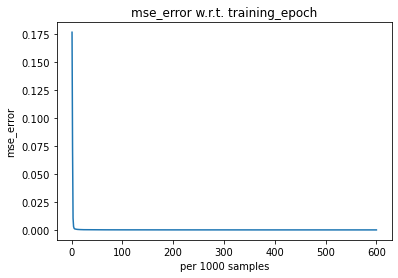

In [23]:
# plot traning log
import matplotlib.pyplot as plt
check_point = 1000
len = int(train_epoch * dataset_size / check_point)

x = np.linspace(1, len, len)
y = [train_loss_log[i].detach().numpy() for i in range(len)]

plt.plot(x,y)
plt.title('mse_error w.r.t. training_epoch')
plt.xlabel('per '+str(check_point)+' samples')
plt.ylabel('mse_error')
plt.show()

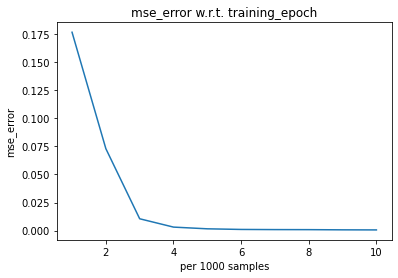

In [26]:
max_length = 10

x_detailed = x[:max_length]
y_detailed = y[:max_length]

plt.plot(x_detailed,y_detailed)
plt.title('mse_error w.r.t. training_epoch')
plt.xlabel('per '+str(check_point)+' samples')
plt.ylabel('mse_error')
plt.show()

In [16]:
# evaluatiuon
eval_loss = eval() # print loss on validation dataset

train_loss = eval_trainset()
print('train_loss is: ', train_loss) # print loss on training dataset

/Users/freyahung/opt/anaconda3/lib/python3.7/site-packages/torch/nn/modules/loss.py:446: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


validation loss is:  tensor(3.7316e-05, grad_fn=<DivBackward0>)
train_loss is:  tensor(2.9552e-05, grad_fn=<DivBackward0>)


In [17]:
# inference
model(features)

tensor([[1.4084],
        [1.0128],
        [1.3377],
        ...,
        [0.9313],
        [0.6688],
        [1.2863]], grad_fn=<AddmmBackward>)

In [21]:
# save model
import datetime
import os

date_time_now = datetime.datetime.now().strftime("%Y-%m-%d_%H:%M:%S") 
PATH = 'trained_model'+ date_time_now
# os.makedirs(PATH) 

saved_model = torch.save(model.state_dict(), PATH)

In [28]:
#use pre-trained model

trained_model_file = 'trained_model_longitudinal' # make sure you are using the correct model you want

#crerate model
trained_model = Net(input_dim, output_dim, emb_dim = [16, 32]) # input/output dimension fixed
print(trained_model(features)) # random initialized

#load trained model
trained_model.load_state_dict(torch.load(trained_model_file), strict = True)
print(trained_model(features)) # same test result as validation


tensor([[-0.1522],
        [-0.1617],
        [-0.1562],
        ...,
        [-0.1774],
        [-0.1574],
        [-0.1708]], grad_fn=<AddmmBackward>)
tensor([[1.4084],
        [1.0128],
        [1.3377],
        ...,
        [0.9313],
        [0.6688],
        [1.2863]], grad_fn=<AddmmBackward>)
